In [ ]:
# core
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt

# sklearn for models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)



In [ ]:
!pip install vaderSentiment
# helper function
utils_path = "/content/utils.py"
import importlib.util

spec = importlib.util.spec_from_file_location("utils_temp", utils_path)
utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(utils)

# use functions
print(utils.clean_txt("Hello WORLD!!"))
print(utils.senti_fun("Stocks are soaring today!"))

hello world
0.0


In [ ]:
# paths
nyt_path = "/content/nyt_tech_news.csv"
smh_path = "/content/smh.xlsx"

nyt = pd.read_csv(nyt_path)
smh = pd.read_excel(smh_path)

print(nyt.head())
print(smh.head())

  keyword                                           headline  \
0    Tech  European Firms Team Up to Target Google in Civ...   
1    Tech  Marissa Mayer of Yahoo Says She’s Pregnant Wit...   
2    Tech  Daily Report: Hotel Chains Get Tough With Trav...   
3    Tech  Big Leaps for Parental Leave, if Workers Actua...   
4    Tech                      Your Tuesday Evening Briefing   

               pub_date              source     section  \
0  2015-09-01T05:00:22Z  The New York Times    Business   
1  2015-09-01T08:21:52Z  The New York Times  Technology   
2  2015-09-01T13:19:56Z  The New York Times  Technology   
3  2015-09-01T17:52:49Z  The New York Times  The Upshot   
4  2015-09-01T21:51:59Z  The New York Times     NYT Now   

                                                 url  \
0  https://www.nytimes.com/2015/09/01/business/in...   
1  https://bits.blogs.nytimes.com/2015/09/01/yaho...   
2  https://bits.blogs.nytimes.com/2015/09/01/dail...   
3  https://www.nytimes.com/2015/09/0

In [ ]:
# Parse pub_date to datetime and keep a pure date column
nyt["pub_date"] = pd.to_datetime(nyt["pub_date"], utc=True, errors="coerce")
nyt["date"] = nyt["pub_date"].dt.date

In [ ]:
import nltk
nltk.download('stopwords')

# Text Preperation
# 1) Combine headline + snippet into a single raw text field
nyt["text_raw"] = (
    nyt["headline"].fillna("").astype(str) + " " +
    nyt["snippet"].fillna("").astype(str)
)


# Clean Text
nyt["text_clean"] = nyt["text_raw"].apply(utils.clean_txt)

# Remove Stopwords
nyt["text_nostop"] = nyt["text_clean"].apply(utils.rem_sw)
print(nyt["text_nostop"])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0       european firms team target google civil lawsui...
1       marissa mayer yahoo says pregnant twins ms may...
2       daily report hotel chains get tough travel web...
3       big leaps parental leave workers actually take...
4              tuesday evening briefing need know end day
                              ...                        
3491    trump tightens visas china woos world science ...
3492    new tariffs shock countries reeling trump chao...
3493    might trump administration go next president s...
3494    trump expands tariffs beyond supreme court rea...
3495    would work hustle culture trend taking hold si...
Name: text_nostop, Length: 3496, dtype: object


In [ ]:
import nltk
nltk.download('wordnet')

# Stemming
nyt["text_stem"] = nyt["text_nostop"].apply(lambda s: utils.stem_fun(s, "porter"))

# Lemmatization
nyt["text_lemma"] = nyt["text_nostop"].apply(lambda s: utils.stem_fun(s, "lemma"))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Quick Check
nyt[["headline", "snippet", "text_clean", "text_nostop", "text_stem", "text_lemma"]].head()

,headline,snippet,text_clean,text_nostop,text_stem,text_lemma
0,European Firms Team Up to Target Google in Civ...,A law firm and public affairs company have cre...,european firms team up to target google in civ...,european firms team target google civil lawsui...,european firm team target googl civil lawsuit ...,european firm team target google civil lawsuit...
1,Marissa Mayer of Yahoo Says She’s Pregnant Wit...,Ms. Mayer said Monday that her twins were due ...,marissa mayer of yahoo says she s pregnant wit...,marissa mayer yahoo says pregnant twins ms may...,marissa mayer yahoo say pregnant twin ms mayer...,marissa mayer yahoo say pregnant twin m mayer ...
2,Daily Report: Hotel Chains Get Tough With Trav...,"For years, hotels have grudgingly let websites...",daily report hotel chains get tough with trave...,daily report hotel chains get tough travel web...,daili report hotel chain get tough travel webs...,daily report hotel chain get tough travel webs...
3,"Big Leaps for Parental Leave, if Workers Actua...",Some companies are offering more generous paid...,big leaps for parental leave if workers actual...,big leaps parental leave workers actually take...,big leap parent leav worker actual take compan...,big leap parental leave worker actually take c...
4,Your Tuesday Evening Briefing,Here’s what you need to know at the end of the...,your tuesday evening briefing here s what you ...,tuesday evening briefing need know end day,tuesday even brief need know end day,tuesday evening briefing need know end day


In [ ]:
# Make a label column from section
nyt["label"] = nyt["section"].fillna("Unknown")

# Build word frequency dictionary over stemmed text
word_dict = utils.word_all_fun(nyt, "text_stem")

# 10 most common words overall
from collections import Counter
Counter(word_dict["all"]).most_common(10)


[('china', 793),
 ('tech', 595),
 ('compani', 523),
 ('new', 511),
 ('u', 503),
 ('trump', 503),
 ('presid', 373),
 ('biden', 362),
 ('chip', 342),
 ('trade', 315)]

In [ ]:
# Sentiment
nyt["sentiment"] = nyt["text_lemma"].apply(utils.senti_fun)

# Quick preview
print(nyt[["headline", "sentiment"]].head())

                                            headline  sentiment
0  European Firms Team Up to Target Google in Civ...    -0.1027
1  Marissa Mayer of Yahoo Says She’s Pregnant Wit...     0.0000
2  Daily Report: Hotel Chains Get Tough With Trav...     0.2263
3  Big Leaps for Parental Leave, if Workers Actua...     0.7269
4                      Your Tuesday Evening Briefing     0.0000


In [ ]:
# Token features using cnt_tok
nyt["n_tokens"] = nyt["text_lemma"].apply(lambda s: utils.cnt_tok(s, "list"))
nyt["n_types"]  = nyt["text_lemma"].apply(lambda s: utils.cnt_tok(s, "set"))
print(nyt[[ "n_tokens", "n_types"]].head())

   n_tokens  n_types
0        24       20
1        17       15
2        26       23
3        20       19
4         7        7


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def senti_all_fun(text):
    scores = analyzer.polarity_scores(text)
    return pd.Series({
        "sent_compound": scores["compound"],
        "sent_neg": scores["neg"],
        "sent_neu": scores["neu"],
        "sent_pos": scores["pos"],
    })

sent_df = nyt["text_raw"].apply(senti_all_fun)
nyt = pd.concat([nyt, sent_df], axis=1)
print(nyt.head())

  keyword                                           headline  \
0    Tech  European Firms Team Up to Target Google in Civ...   
1    Tech  Marissa Mayer of Yahoo Says She’s Pregnant Wit...   
2    Tech  Daily Report: Hotel Chains Get Tough With Trav...   
3    Tech  Big Leaps for Parental Leave, if Workers Actua...   
4    Tech                      Your Tuesday Evening Briefing   

                   pub_date              source     section  \
0 2015-09-01 05:00:22+00:00  The New York Times    Business   
1 2015-09-01 08:21:52+00:00  The New York Times  Technology   
2 2015-09-01 13:19:56+00:00  The New York Times  Technology   
3 2015-09-01 17:52:49+00:00  The New York Times  The Upshot   
4 2015-09-01 21:51:59+00:00  The New York Times     NYT Now   

                                                 url  \
0  https://www.nytimes.com/2015/09/01/business/in...   
1  https://bits.blogs.nytimes.com/2015/09/01/yaho...   
2  https://bits.blogs.nytimes.com/2015/09/01/dail...   
3  https://w

In [ ]:
# Aggregate sentiment by date
daily_sent = (
    nyt.groupby("date", as_index=False)
       .agg(
           sentiment_mean=("sentiment", "mean"),
           sentiment_std=("sentiment", "std"),
           n_articles=("sentiment", "size")
       )
)
# Convert date column to datetime64[ns] for consistent merging
daily_sent["date"] = pd.to_datetime(daily_sent["date"])

# Clean NA std (days with 1 article)
daily_sent["sentiment_std"] = daily_sent["sentiment_std"].fillna(0)

daily_sent.head()


,date,sentiment_mean,sentiment_std,n_articles
0,2015-09-01,0.170100,0.333719,5
1,2015-09-02,-0.147733,0.584525,12
2,2015-09-03,-0.040110,0.553447,10
3,2015-09-04,0.274738,0.327655,8
4,2015-09-05,0.146200,0.243245,2


In [ ]:
# Clean SMH dates and returns
smh.columns = smh.columns.str.strip().str.lower() # Convert all columns to lowercase
smh["date"] = pd.to_datetime(smh["date"], errors="coerce")
smh = smh.sort_values("date")

smh["ret"] = smh["adj close"].pct_change(fill_method=None)
print(smh.head())

        date   open   high    low  close  adj close       ret
0 2015-09-01  24.28  24.51  23.84  24.00      21.47       NaN
1 2015-09-02  24.49  24.61  24.22  24.60      22.00  0.024686
2 2015-09-03  24.82  25.13  24.75  24.84      22.22  0.010000
3 2015-09-04  24.58  24.68  24.33  24.45      21.87 -0.015752
4 2015-09-08  25.05  25.42  24.99  25.39      22.70  0.037952


In [ ]:
# Merge sentiment + SMH
data_daily = (
    smh[["date", "adj close", "ret"]]
      .merge(daily_sent, left_on="date", right_on="date", how="left")
      # .drop(columns=["date"]) # Remove this line to keep the 'date' column
)

data_daily["sentiment_mean"] = data_daily["sentiment_mean"].fillna(0)
data_daily["sentiment_std"] = data_daily["sentiment_std"].fillna(0)
data_daily["n_articles"] = data_daily["n_articles"].fillna(0)

print(data_daily.head())


        date  adj close       ret  sentiment_mean  sentiment_std  n_articles
0 2015-09-01      21.47       NaN        0.170100       0.333719         5.0
1 2015-09-02      22.00  0.024686       -0.147733       0.584525        12.0
2 2015-09-03      22.22  0.010000       -0.040110       0.553447        10.0
3 2015-09-04      21.87 -0.015752        0.274738       0.327655         8.0
4 2015-09-08      22.70  0.037952        0.022550       0.399548         8.0


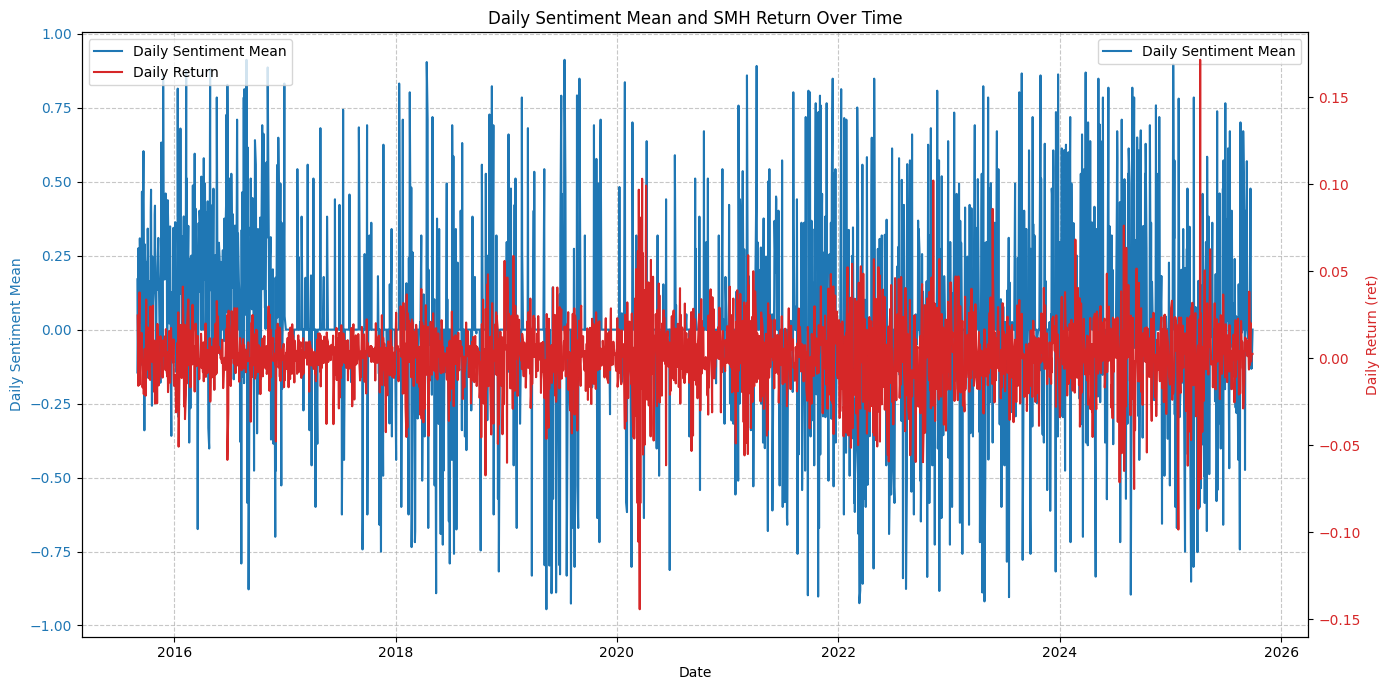

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot sentiment mean on the first y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Sentiment Mean', color=color)
sns.lineplot(x='date', y='sentiment_mean', data=data_daily, ax=ax1, color=color, label='Daily Sentiment Mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Daily Sentiment Mean and SMH Return Over Time')
ax1.grid(True, linestyle='--', alpha=0.7)

# Instantiate a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Daily Return (ret)', color=color)
sns.lineplot(x='date', y='ret', data=data_daily, ax=ax2, color=color, label='Daily Return')
ax2.tick_params(axis='y', labelcolor=color)

# Add legends for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Create 3-day forward return
data_daily["ret_3d"] = (
    np.log(data_daily["adj close"].shift(-3)) -
    np.log(data_daily["adj close"])
)
data_daily["y_3d"] = (data_daily["ret_3d"] > 0).astype(int)

print("Final rows:", len(data_daily))
print(data_daily.head())


Final rows: 2545
        date  adj close       ret  sentiment_mean  sentiment_std  n_articles  \
0 2015-09-01      21.47       NaN        0.170100       0.333719         5.0   
1 2015-09-02      22.00  0.024686       -0.147733       0.584525        12.0   
2 2015-09-03      22.22  0.010000       -0.040110       0.553447        10.0   
3 2015-09-04      21.87 -0.015752        0.274738       0.327655         8.0   
4 2015-09-08      22.70  0.037952        0.022550       0.399548         8.0   

     ret_3d  y_3d  
0  0.018459     1  
1  0.031322     1  
2  0.006281     1  
3  0.025284     1  
4 -0.010184     0  


In [ ]:
# Minimal lags & simple rolling features
data_daily["ret_lag1"] = data_daily["ret"].shift(1)
data_daily["ret_lag2"] = data_daily["ret"].shift(2)

data_daily["sent_3d"] = data_daily["sentiment_mean"].rolling(3).mean()
data_daily["sent_vol_3d"] = data_daily["sentiment_mean"].rolling(3).std()


In [ ]:
full_df_model = data_daily.dropna(
    subset=[
        "sentiment_mean", "sentiment_std", "n_articles",
        "ret", "ret_lag1",
        "sent_3d", "sent_vol_3d",
        "ret_3d", "y_3d"
    ]
).copy()

print("Final rows:", len(full_df_model))
full_df_model.head()


Final rows: 2496


,date,adj close,ret,sentiment_mean,sentiment_std,n_articles,ret_3d,y_3d,ret_lag1,ret_lag2,sent_3d,sent_vol_3d
2,2015-09-03,22.22,0.010000,-0.040110,0.553447,10.0,0.006281,1,0.024686,NaN,-0.005914,0.161652
3,2015-09-04,21.87,-0.015752,0.274738,0.327655,8.0,0.025284,1,0.010000,0.024686,0.028965,0.219542
4,2015-09-08,22.70,0.037952,0.022550,0.399548,8.0,-0.010184,0,-0.015752,0.010000,0.085726,0.166660
5,2015-09-09,22.36,-0.014978,0.308427,0.408464,15.0,0.007574,1,0.037952,-0.015752,0.201905,0.156236
6,2015-09-10,22.43,0.003131,0.227829,0.374381,7.0,0.018989,1,-0.014978,0.037952,0.186268,0.147400


In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature matrix + labels
feature_cols = [
    "sentiment_mean",
    "sentiment_std",
    "n_articles",
    "ret_lag1",
    "sent_3d",
    "sent_vol_3d",
]

X       = full_df_model[feature_cols].values
y_class = full_df_model["y_3d"].values      # classification target
y_reg   = full_df_model["ret_3d"].values    # regression target
dates   = full_df_model["date"].values # Access 'date' with lowercase 'd'

# Time-series split (e.g., 70% train / 30% test)
test_frac = 0.30
n_obs     = len(full_df_model)
split_idx = int(n_obs * (1 - test_frac))

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train     = y_class[:split_idx]
y_test      = y_class[split_idx:]

y_ret_train = y_reg[:split_idx]
y_ret_test  = y_reg[split_idx:]

dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

print("Train size:", X_train_raw.shape[0])
print("Test size :", X_test_raw.shape[0])

# Scale AFTER splitting (for linear / distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)


Train size: 1747
Test size : 749


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

clf_models = {
    "Logistic (balanced)": LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        solver="lbfgs"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

clf_results = {}
print("\n==============================")
print(" CLASSIFICATION: 3-day Direction ")
print("==============================")

for name, model in clf_models.items():
    # Logistic uses scaled features; tree models use raw
    if isinstance(model, LogisticRegression):
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_raw, X_test_raw

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    print(f"\n=== {name} ===")
    print("Accuracy :", round(acc, 3))
    print("Precision:", round(prec, 3))
    print("Recall   :", round(rec, 3))
    print("F1       :", round(f1, 3))
    print("Confusion:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n",
          classification_report(y_test, y_pred, digits=3, zero_division=0))

    clf_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

# Small summary table
clf_summary = (
    pd.DataFrame([
        {"model": k,
         "accuracy": v["accuracy"],
         "precision": v["precision"],
         "recall": v["recall"],
         "f1": v["f1"]}
        for k, v in clf_results.items()
    ])
    .sort_values("f1", ascending=False)
)
print("\nSummary (sorted by F1):\n", clf_summary)



 CLASSIFICATION: 3-day Direction 

=== Logistic (balanced) ===
Accuracy : 0.47
Precision: 0.484
Recall   : 0.47
F1       : 0.473
Confusion:
 [[156 162]
 [235 196]]
Classification report:
               precision    recall  f1-score   support

           0      0.399     0.491     0.440       318
           1      0.547     0.455     0.497       431

    accuracy                          0.470       749
   macro avg      0.473     0.473     0.468       749
weighted avg      0.484     0.470     0.473       749


=== RandomForest ===
Accuracy : 0.541
Precision: 0.494
Recall   : 0.541
F1       : 0.48
Confusion:
 [[ 47 271]
 [ 73 358]]
Classification report:
               precision    recall  f1-score   support

           0      0.392     0.148     0.215       318
           1      0.569     0.831     0.675       431

    accuracy                          0.541       749
   macro avg      0.480     0.489     0.445       749
weighted avg      0.494     0.541     0.480       749


=== Grad

In [ ]:
test_frac = 0.30
n = len(full_df_model)
split_idx = int(n * (1 - test_frac))

# Ensure X and y_reg are from the 3-day task (from zKZiZ5gKtkNr)
X_reg_features = X # X is already global from zKZiZ5gKtkNr
y_reg_target = y_reg # y_reg is already global from zKZiZ5gKtkNr

X_train_raw_reg = X_reg_features[:split_idx]
X_test_raw_reg  = X_reg_features[split_idx:]

y_train_reg = y_reg_target[:split_idx]
y_test_reg  = y_reg_target[split_idx:]

# Scale for Ridge model
from sklearn.preprocessing import StandardScaler
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_raw_reg)
X_test_reg_scaled  = scaler_reg.transform(X_test_raw_reg)


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reg_models = {
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ),
    "Ridge": Ridge(alpha=1.0)
}

reg_results = {}

print("\n==============================")
print(" REGRESSION: 3-day Return ")
print("=============================")

for name, model in reg_models.items():

    # Ridge uses scaled features; tree models use raw
    if isinstance(model, Ridge):
        X_tr, X_te = X_train_reg_scaled, X_test_reg_scaled
    else:
        X_tr, X_te = X_train_raw_reg, X_test_raw_reg

    model.fit(X_tr, y_train_reg)
    y_pred = model.predict(X_te)

    mse = mean_squared_error(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2  = r2_score(y_test_reg, y_pred)

    print(f"\n--- {name} ---")
    print("MSE:", round(mse, 6))
    print("MAE:", round(mae, 6))
    print("R^2:", round(r2, 3))

    reg_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "mse": mse,
        "mae": mae,
        "r2": r2
    }

reg_summary = (
    pd.DataFrame([
        {"model": k, "mse": v["mse"], "mae": v["mae"], "r2": v["r2"]}
        for k, v in reg_results.items()
    ])
    .sort_values("r2", ascending=False)
)

print("\nSummary (sorted by R^2):\n", reg_summary)



 REGRESSION: 3-day Return 

--- RandomForestRegressor ---
MSE: 0.001404
MAE: 0.028358
R^2: -0.015

--- GradientBoostingRegressor ---
MSE: 0.001688
MAE: 0.030922
R^2: -0.219

--- Ridge ---
MSE: 0.001398
MAE: 0.028421
R^2: -0.01

Summary (sorted by R^2):
                        model       mse       mae        r2
2                      Ridge  0.001398  0.028421 -0.009811
0      RandomForestRegressor  0.001404  0.028358 -0.014569
1  GradientBoostingRegressor  0.001688  0.030922 -0.219114


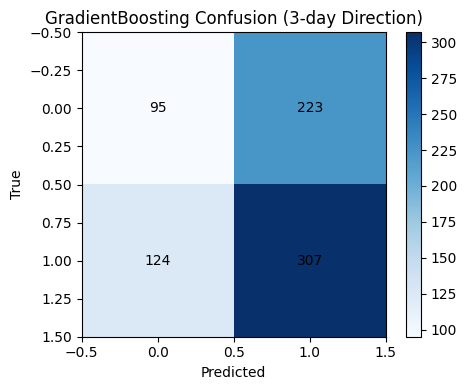

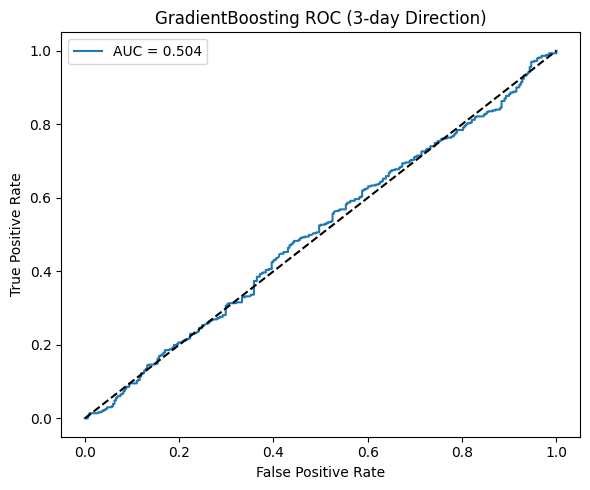

/tmp/ipython-input-409067161.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision[::-1], recall[::-1])


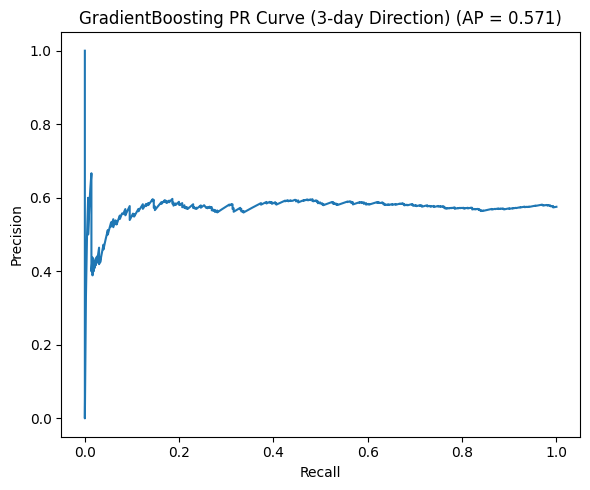

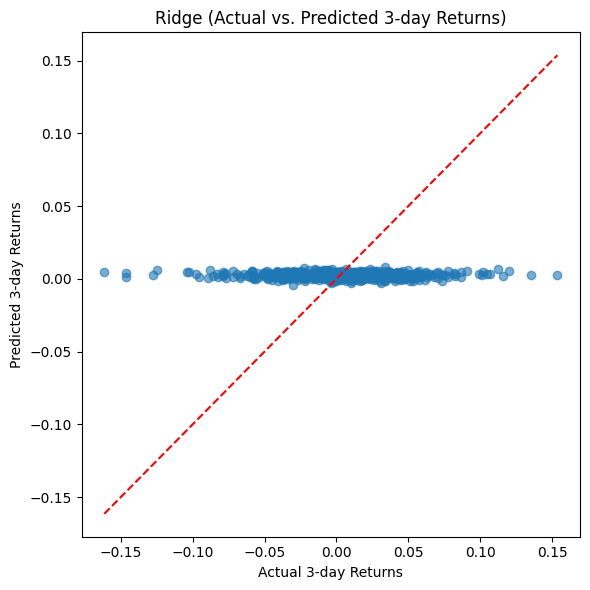

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

plt.style.use("default")

# ---------- Confusion matrix ----------
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    va="center", ha="center", color="black")

    plt.tight_layout()
    plt.show()

# Choose the best classifier by F1 (for example)
best_clf_name = clf_summary.iloc[0]["model"]
best_clf      = clf_results[best_clf_name]["model"]
best_y_pred   = clf_results[best_clf_name]["y_pred"]

plot_confusion_matrix(y_test, best_y_pred,
                      title=f"{best_clf_name} Confusion (3-day Direction)")

# ---------- ROC curve ----------
def plot_roc(model, X_te, y_true, title):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        # e.g. SVM without probas; fall back to decision_function
        y_score = model.decision_function(X_te)
        # convert to [0,1] via min-max
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Use scaled or raw features depending on model:
if isinstance(best_clf, LogisticRegression):
    X_te_for_roc = X_test
else:
    X_te_for_roc = X_test_raw

plot_roc(best_clf, X_te_for_roc, y_test,
         title=f"{best_clf_name} ROC (3-day Direction)")

# ---------- Precision–Recall curve ----------
def plot_pr(model, X_te, y_true, title):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = np.trapz(precision[::-1], recall[::-1])

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP = {ap:.3f})")
    plt.tight_layout()
    plt.show()

plot_pr(best_clf, X_te_for_roc, y_test,
        title=f"{best_clf_name} PR Curve (3-day Direction)")

# ---------- Actual vs. predicted 3-day returns for best regressor ----------
best_reg_name = reg_summary.iloc[0]["model"]
best_reg      = reg_results[best_reg_name]["model"]
best_reg_pred = reg_results[best_reg_name]["y_pred"]

plt.figure(figsize=(6, 6))
plt.scatter(y_ret_test, best_reg_pred, alpha=0.6)
lims = [min(y_ret_test.min(), best_reg_pred.min()),
        max(y_ret_test.max(), best_reg_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual 3-day Returns")
plt.ylabel("Predicted 3-day Returns")
plt.title(f"{best_reg_name} (Actual vs. Predicted 3-day Returns)")
plt.tight_layout()
plt.show()


# Task
Enhance the existing classification and regression models by programmatically fetching VIX and S&P 500 data using `yfinance`, integrating these new features into the `data_daily` DataFrame, updating the feature columns, and then re-training and evaluating the models to assess the impact of VIX and market index returns on their performance.

## Fetch VIX and Market Index Data Programmatically

### Subtask:
Fetch VIX and market index return data programmatically using `yfinance` for the date range covered by the `data_daily` DataFrame.


**Reasoning**:
The first step to fetch data using `yfinance` is to install the library, and it's good practice to install it in a separate cell.



In [ ]:
pip install yfinance

**Reasoning**:
Now that `yfinance` is installed, I need to import the library and determine the date range from the `data_daily` DataFrame to fetch the VIX and S&P 500 data.



In [ ]:
import yfinance as yf

# Determine the date range from data_daily
start_date = data_daily["date"].min()
end_date = data_daily["date"].max()

# Fetch VIX data
vix_data = yf.download("^VIX", start=start_date, end=end_date)

# Fetch S&P 500 data
sp500_data = yf.download("^GSPC", start=start_date, end=end_date)

# Print the first few rows of both DataFrames
print("VIX Data Head:")
print(vix_data.head())
print("\nS&P 500 Data Head:")
print(sp500_data.head())

/tmp/ipython-input-536112652.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data = yf.download("^VIX", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-536112652.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download("^GSPC", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

VIX Data Head:
Price           Close       High        Low       Open Volume
Ticker           ^VIX       ^VIX       ^VIX       ^VIX   ^VIX
Date                                                         
2015-09-01  31.400000  33.820000  29.910000  31.910000      0
2015-09-02  26.090000  30.450001  24.770000  29.139999      0
2015-09-03  25.610001  26.309999  23.450001  25.209999      0
2015-09-04  27.799999  29.469999  25.680000  27.430000      0
2015-09-08  24.900000  26.250000  24.129999  25.049999      0

S&P 500 Data Head:
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2015-09-01  1913.849976  1970.089966  1903.069946  1970.089966  4371850000
2015-09-02  1948.859985  1948.910034  1916.520020  1916.520020  3742620000
2015-09-03  1951.130005  1975.010010  1944.719971  1950.790039  3520700000
2015-09-04  1921.21

# Task
Merge the VIX and S&P 500 DataFrames (`vix_data` and `sp500_data`) with the `data_daily` DataFrame on the 'date' column. Calculate daily returns for VIX and S&P 500, rename the columns for clarity, and fill any resulting missing values. Then, print the head of the updated `data_daily` DataFrame and its info to verify the merge and data types.

## Merge VIX and S&P 500 Data with data_daily

### Subtask:
Integrate the processed VIX and S&P 500 DataFrames (`vix_data` and `sp500_data`) into the `data_daily` DataFrame. This will be done by merging on the 'date' column. Handle any missing values that arise from the merge appropriately (e.g., fill with 0 or forward fill).


**Reasoning**:
I need to prepare the `vix_data` and `sp500_data` DataFrames for merging by resetting their index, renaming the date column for consistency, and renaming the 'Close' columns to be more descriptive. This is the first step towards integrating these new features.



In [ ]:
vix_data = vix_data.reset_index()
sp500_data = sp500_data.reset_index()

vix_data = vix_data.rename(columns={'Date': 'date', 'Close': 'vix_close'})
sp500_data = sp500_data.rename(columns={'Date': 'date', 'Close': 'sp500_close'})

print("VIX Data after renaming columns:")
print(vix_data.head())
print("\nS&P 500 Data after renaming columns:")
print(sp500_data.head())

VIX Data after renaming columns:
Price  index       date  vix_close       High        Low       Open Volume
Ticker                        ^VIX       ^VIX       ^VIX       ^VIX   ^VIX
0          0 2015-09-01  31.400000  33.820000  29.910000  31.910000      0
1          1 2015-09-02  26.090000  30.450001  24.770000  29.139999      0
2          2 2015-09-03  25.610001  26.309999  23.450001  25.209999      0
3          3 2015-09-04  27.799999  29.469999  25.680000  27.430000      0
4          4 2015-09-08  24.900000  26.250000  24.129999  25.049999      0

S&P 500 Data after renaming columns:
Price        date  sp500_close         High          Low         Open  \
Ticker                   ^GSPC        ^GSPC        ^GSPC        ^GSPC   
0      2015-09-01  1913.849976  1970.089966  1903.069946  1970.089966   
1      2015-09-02  1948.859985  1948.910034  1916.520020  1916.520020   
2      2015-09-03  1951.130005  1975.010010  1944.719971  1950.790039   
3      2015-09-04  1921.219971  1947.76

**Reasoning**:
The previous code failed because the column flattening logic after `reset_index()` incorrectly extracted the second element of multi-level column tuples instead of the first, leading to a `KeyError: 'date'` during renaming. I will correct the column flattening to extract the first element of multi-level tuples, ensuring `Close` becomes `Close` and `Date` remains `Date`, then rename them for consistency before calculating returns and merging.



In [ ]:
import yfinance as yf

# Determine the date range from data_daily (already available)
start_date = data_daily["date"].min()
end_date = data_daily["date"].max()

# Re-fetch raw data to ensure correct structure
# Using auto_adjust=False to get the 'Close' column clearly
raw_vix_data = yf.download("^VIX", start=start_date, end=end_date, auto_adjust=False)
raw_sp500_data = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=False)

# Reset index to make 'Date' a regular column
vix_df = raw_vix_data.reset_index()
sp500_df = raw_sp500_data.reset_index()

# Flatten the MultiIndex columns. 'Date' is already flat after reset_index.
# For other columns, take the first level of the tuple (e.g., ('Close', '^VIX') becomes 'Close')
vix_df.columns = [col[0] if isinstance(col, tuple) else col for col in vix_df.columns]
sp500_df.columns = [col[0] if isinstance(col, tuple) else col for col in sp500_df.columns]

# Rename 'Date' to 'date' for consistency and 'Close' to descriptive names
vix_df = vix_df.rename(columns={'Date': 'date', 'Close': 'vix_close'})
sp500_df = sp500_df.rename(columns={'Date': 'date', 'Close': 'sp500_close'})

# Convert date column to datetime objects
vix_df["date"] = pd.to_datetime(vix_df["date"])
sp500_df["date"] = pd.to_datetime(sp500_df["date"])

# Calculate daily returns
vix_df["vix_ret"] = vix_df["vix_close"].pct_change()
sp500_df["sp500_ret"] = sp500_df["sp500_close"].pct_change()

# Merge VIX data
data_daily = data_daily.merge(
    vix_df[["date", "vix_close", "vix_ret"]],
    on="date",
    how="left"
)

# Merge S&P 500 data
data_daily = data_daily.merge(
    sp500_df[["date", "sp500_close", "sp500_ret"]],
    on="date",
    how="left"
)

# Fill NaN values for new columns (using 0 for simplicity)
data_daily["vix_close"] = data_daily["vix_close"].fillna(0)
data_daily["vix_ret"] = data_daily["vix_ret"].fillna(0)
data_daily["sp500_close"] = data_daily["sp500_close"].fillna(0)
data_daily["sp500_ret"] = data_daily["sp500_ret"].fillna(0)

print("Updated data_daily head:")
print(data_daily.head())
print("\nUpdated data_daily info:")
data_daily.info()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Updated data_daily head:
        date  adj close       ret  sentiment_mean  sentiment_std  n_articles  \
0 2015-09-01      21.47       NaN        0.170100       0.333719         5.0   
1 2015-09-02      22.00  0.024686       -0.147733       0.584525        12.0   
2 2015-09-03      22.22  0.010000       -0.040110       0.553447        10.0   
3 2015-09-04      21.87 -0.015752        0.274738       0.327655         8.0   
4 2015-09-08      22.70  0.037952        0.022550       0.399548         8.0   

     ret_3d  y_3d  ret_lag1  ret_lag2   sent_3d  sent_vol_3d  vix_close  \
0  0.018459     1       NaN       NaN       NaN          NaN  31.400000   
1  0.031322     1       NaN       NaN       NaN          NaN  26.090000   
2  0.006281     1  0.024686       NaN -0.005914     0.161652  25.610001   
3  0.025284     1  0.010000  0.024686  0.028965     0.219542  27.799999   
4 -0.010184     0 -0.015752  0.010000  0.085726     0.166660  24.900000   

    vix_ret  sp500_close  sp500_ret  
0  0.

**Reasoning**:
The previous steps successfully merged VIX and S&P 500 data into `data_daily`. Now, I need to update the `full_df_model` DataFrame, redefine the feature columns to include the new VIX and S&P 500 returns, and then re-split and re-scale the data for model training, as per the task requirements.



In [ ]:
full_df_model = data_daily.dropna(
    subset=[
        "sentiment_mean", "sentiment_std", "n_articles",
        "ret", "ret_lag1",
        "sent_3d", "sent_vol_3d",
        "ret_3d", "y_3d",
        "vix_ret", "sp500_ret" # Include new features for dropping NAs
    ]
).copy()

print("Final rows:", len(full_df_model))

from sklearn.preprocessing import StandardScaler

# Feature matrix + labels
feature_cols = [
    "sentiment_mean",
    "sentiment_std",
    "n_articles",
    "ret_lag1",
    "sent_3d",
    "sent_vol_3d",
    "vix_ret", # New VIX return feature
    "sp500_ret" # New S&P 500 return feature
]

X       = full_df_model[feature_cols].values
y_class = full_df_model["y_3d"].values      # classification target
y_reg   = full_df_model["ret_3d"].values    # regression target
dates   = full_df_model["date"].values

# Time-series split (e.g., 70% train / 30% test)
test_frac = 0.30
n_obs     = len(full_df_model)
split_idx = int(n_obs * (1 - test_frac))

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train     = y_class[:split_idx]
y_test      = y_class[split_idx:]

y_ret_train = y_reg[:split_idx]
y_ret_test  = y_reg[split_idx:]

dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

print("Train size:", X_train_raw.shape[0])
print("Test size :", X_test_raw.shape[0])

# Scale AFTER splitting (for linear / distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# For regression models that need scaling
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_raw)
X_test_reg_scaled  = scaler_reg.transform(X_test_raw)

print("Features updated and data re-split and re-scaled.")

Final rows: 2496
Train size: 1747
Test size : 749
Features updated and data re-split and re-scaled.


## Create New Features

### Subtask:
Generate additional features from the newly merged VIX and S&P 500 data. This involves creating lagged versions of VIX and S&P 500 returns (e.g., `vix_ret_lag1`, `sp500_ret_lag1`) and rolling statistics (e.g., 3-day rolling mean of VIX, 3-day rolling standard deviation of S&P 500 returns) to capture temporal dependencies and volatility.


**Reasoning**:
I will create lagged and rolling features for VIX and S&P 500 data within the `full_df_model` DataFrame, following the instructions to add `vix_ret_lag1`, `sp500_ret_lag1`, `vix_3d_mean`, and `sp500_3d_std`.



In [ ]:
full_df_model["vix_ret_lag1"] = full_df_model["vix_ret"].shift(1)
full_df_model["sp500_ret_lag1"] = full_df_model["sp500_ret"].shift(1)
full_df_model["vix_3d_mean"] = full_df_model["vix_close"].rolling(3).mean()
full_df_model["sp500_3d_std"] = full_df_model["sp500_ret"].rolling(3).std()

print(full_df_model.head())

        date  adj close       ret  sentiment_mean  sentiment_std  n_articles  \
2 2015-09-03      22.22  0.010000       -0.040110       0.553447        10.0   
3 2015-09-04      21.87 -0.015752        0.274738       0.327655         8.0   
4 2015-09-08      22.70  0.037952        0.022550       0.399548         8.0   
5 2015-09-09      22.36 -0.014978        0.308427       0.408464        15.0   
6 2015-09-10      22.43  0.003131        0.227829       0.374381         7.0   

     ret_3d  y_3d  ret_lag1  ret_lag2   sent_3d  sent_vol_3d  vix_close  \
2  0.006281     1  0.024686       NaN -0.005914     0.161652  25.610001   
3  0.025284     1  0.010000  0.024686  0.028965     0.219542  27.799999   
4 -0.010184     0 -0.015752  0.010000  0.085726     0.166660  24.900000   
5  0.007574     1  0.037952 -0.015752  0.201905     0.156236  26.230000   
6  0.018989     1 -0.014978  0.037952  0.186268     0.147400  24.370001   

    vix_ret  sp500_close  sp500_ret  vix_ret_lag1  sp500_ret_lag1  \

**Reasoning**:
The new lagged and rolling features introduced NaN values. I need to drop these rows from `full_df_model` and then update the feature columns to include the newly created features. Afterward, I will re-split and re-scale the data, including these new features, to prepare for model re-training and evaluation.



In [ ]:
full_df_model = full_df_model.dropna(
    subset=[
        "sentiment_mean", "sentiment_std", "n_articles",
        "ret", "ret_lag1",
        "sent_3d", "sent_vol_3d",
        "ret_3d", "y_3d",
        "vix_ret", "sp500_ret",
        "vix_ret_lag1", "sp500_ret_lag1",
        "vix_3d_mean", "sp500_3d_std"
    ]
).copy()

print("Final rows after dropping NAs with new features:", len(full_df_model))

# Feature matrix + labels
feature_cols = [
    "sentiment_mean",
    "sentiment_std",
    "n_articles",
    "ret_lag1",
    "sent_3d",
    "sent_vol_3d",
    "vix_ret",
    "sp500_ret",
    "vix_ret_lag1", # New VIX lagged return feature
    "sp500_ret_lag1", # New S&P 500 lagged return feature
    "vix_3d_mean", # New VIX 3-day mean feature
    "sp500_3d_std" # New S&P 500 3-day std feature
]

X       = full_df_model[feature_cols].values
y_class = full_df_model["y_3d"].values      # classification target
y_reg   = full_df_model["ret_3d"].values    # regression target
dates   = full_df_model["date"].values

# Time-series split (e.g., 70% train / 30% test)
test_frac = 0.30
n_obs     = len(full_df_model)
split_idx = int(n_obs * (1 - test_frac))

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train     = y_class[:split_idx]
y_test      = y_class[split_idx:]

y_ret_train = y_reg[:split_idx]
y_ret_test  = y_reg[split_idx:]

dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

print("Train size:", X_train_raw.shape[0])
print("Test size :", X_test_raw.shape[0])

# Scale AFTER splitting (for linear / distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# For regression models that need scaling
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_raw)
X_test_reg_scaled  = scaler_reg.transform(X_test_raw)

print("Features updated and data re-split and re-scaled.")

Final rows after dropping NAs with new features: 2494
Train size: 1745
Test size : 749
Features updated and data re-split and re-scaled.


**Reasoning**:
The data has been re-split and re-scaled with the new features. Now, I need to re-train the classification models using the updated training data and then evaluate their performance on the test set. This will allow for assessing the impact of the VIX and S&P 500 features on the classification task.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

clf_models = {
    "Logistic (balanced)": LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        solver="lbfgs"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

clf_results = {}
print("\n==============================")
print(" CLASSIFICATION: 3-day Direction ")
print("==============================")

for name, model in clf_models.items():
    # Logistic uses scaled features; tree models use raw
    if isinstance(model, LogisticRegression):
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_raw, X_test_raw

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    print(f"\n=== {name} ===")
    print("Accuracy :", round(acc, 3))
    print("Precision:", round(prec, 3))
    print("Recall   :", round(rec, 3))
    print("F1       :", round(f1, 3))
    print("Confusion:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n",
          classification_report(y_test, y_pred, digits=3, zero_division=0))

    clf_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

# Small summary table
clf_summary = (
    pd.DataFrame([
        {"model": k,
         "accuracy": v["accuracy"],
         "precision": v["precision"],
         "recall": v["recall"],
         "f1": v["f1"]}
        for k, v in clf_results.items()
    ])
    .sort_values("f1", ascending=False)
)
print("\nSummary (sorted by F1):\n", clf_summary)


 CLASSIFICATION: 3-day Direction 

=== Logistic (balanced) ===
Accuracy : 0.462
Precision: 0.482
Recall   : 0.462
F1       : 0.463
Confusion:
 [[170 148]
 [255 176]]
Classification report:
               precision    recall  f1-score   support

           0      0.400     0.535     0.458       318
           1      0.543     0.408     0.466       431

    accuracy                          0.462       749
   macro avg      0.472     0.471     0.462       749
weighted avg      0.482     0.462     0.463       749


=== RandomForest ===
Accuracy : 0.577
Precision: 0.552
Recall   : 0.577
F1       : 0.503
Confusion:
 [[ 46 272]
 [ 45 386]]
Classification report:
               precision    recall  f1-score   support

           0      0.505     0.145     0.225       318
           1      0.587     0.896     0.709       431

    accuracy                          0.577       749
   macro avg      0.546     0.520     0.467       749
weighted avg      0.552     0.577     0.503       749


=== G

**Reasoning**:
The classification models have been re-trained and evaluated with the updated features. Now, I need to re-train the regression models with the updated feature set (including VIX and S&P 500 features) and evaluate their performance to assess the impact of these new features on the regression task.



In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reg_models = {
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ),
    "Ridge": Ridge(alpha=1.0)
}

reg_results = {}

print("\n==============================")
print(" REGRESSION: 3-day Return ")
print("=============================")

# Re-slice y_ret_train and y_ret_test to ensure consistency with current X_train_raw/X_test_raw
y_ret_train = y_reg[:split_idx]
y_ret_test  = y_reg[split_idx:]

for name, model in reg_models.items():

    # Ridge uses scaled features; tree models use raw
    if isinstance(model, Ridge):
        X_tr, X_te = X_train_reg_scaled, X_test_reg_scaled
    else:
        X_tr, X_te = X_train_raw, X_test_raw

    model.fit(X_tr, y_ret_train)
    y_pred = model.predict(X_te)

    mse = mean_squared_error(y_ret_test, y_pred)
    mae = mean_absolute_error(y_ret_test, y_pred)
    r2  = r2_score(y_ret_test, y_pred)

    print(f"\n--- {name} ---")
    print("MSE:", round(mse, 6))
    print("MAE:", round(mae, 6))
    print("R^2:", round(r2, 3))

    reg_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "mse": mse,
        "mae": mae,
        "r2": r2
    }

reg_summary = (
    pd.DataFrame([
        {"model": k, "mse": v["mse"], "mae": v["mae"], "r2": v["r2"]}
        for k, v in reg_results.items()
    ])
    .sort_values("r2", ascending=False)
)

print("\nSummary (sorted by R^2):\n", reg_summary)



 REGRESSION: 3-day Return 

--- RandomForestRegressor ---
MSE: 0.00139
MAE: 0.028348
R^2: -0.004

--- GradientBoostingRegressor ---
MSE: 0.001471
MAE: 0.029179
R^2: -0.063

--- Ridge ---
MSE: 0.001384
MAE: 0.028437
R^2: 0.0

Summary (sorted by R^2):
                        model       mse       mae        r2
2                      Ridge  0.001384  0.028437  0.000037
0      RandomForestRegressor  0.001390  0.028348 -0.004226
1  GradientBoostingRegressor  0.001471  0.029179 -0.062970


## Visualize New Model Performance

### Subtask:
Generate new visualizations to display the updated model performance. This includes new confusion matrices, ROC curves, and Precision-Recall curves for the best classification model, and an actual vs. predicted plot for the best regression model, allowing for a clear comparison of results before and after feature enhancement. Provide legends for all plots generated.


**Reasoning**:
The subtask requires visualizing the updated model performance by generating new confusion matrices, ROC curves, Precision-Recall curves for the best classification model, and an actual vs. predicted plot for the best regression model. The `plot_confusion_matrix`, `plot_roc`, and `plot_pr` functions are already defined and will be reused. I will also generate the regression plot as instructed.



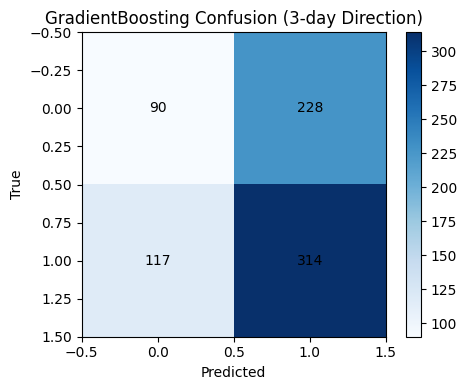

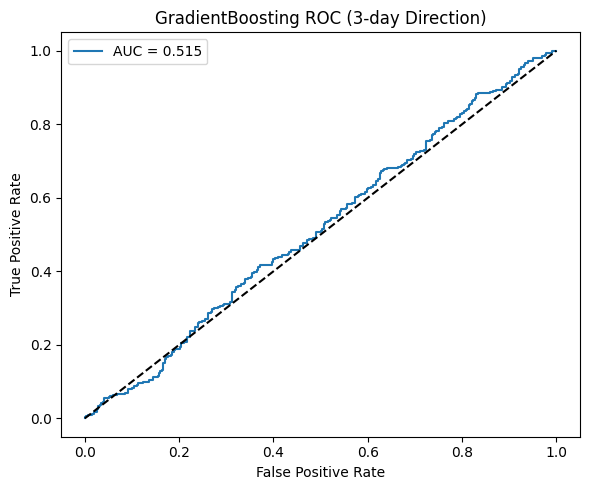

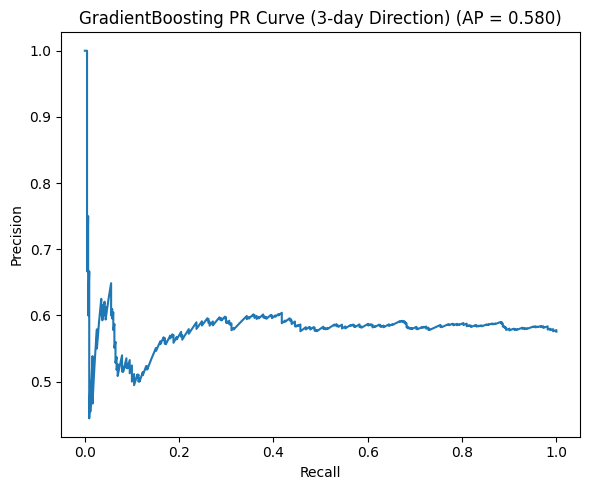

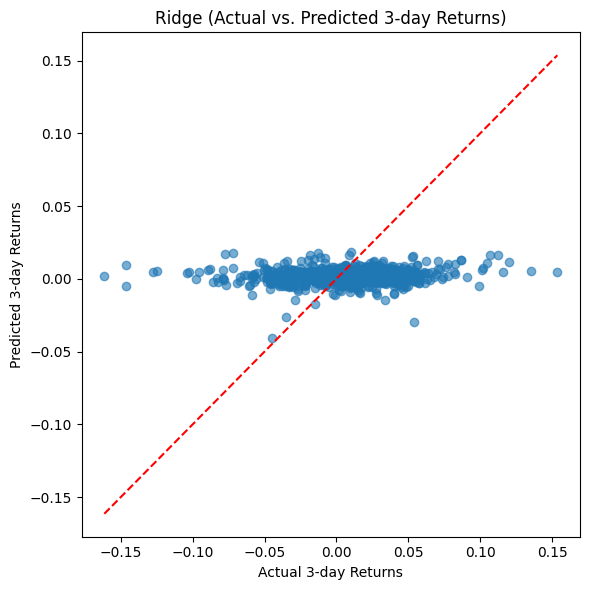

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

plt.style.use("default")

# ---------- Confusion matrix ----------
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    va="center", ha="center", color="black")

    plt.tight_layout()
    plt.show()

# Choose the best classifier by F1 (for example)
best_clf_name = clf_summary.iloc[0]["model"]
best_clf      = clf_results[best_clf_name]["model"]
best_y_pred   = clf_results[best_clf_name]["y_pred"]

plot_confusion_matrix(y_test, best_y_pred,
                      title=f"{best_clf_name} Confusion (3-day Direction)")

# ---------- ROC curve ----------
def plot_roc(model, X_te, y_true, title):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        # e.g. SVM without probas; fall back to decision_function
        y_score = model.decision_function(X_te)
        # convert to [0,1] via min-max
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Use scaled or raw features depending on model:
if isinstance(best_clf, LogisticRegression):
    X_te_for_roc = X_test
else:
    X_te_for_roc = X_test_raw

plot_roc(best_clf, X_te_for_roc, y_test,
         title=f"{best_clf_name} ROC (3-day Direction)")

# ---------- Precision–Recall curve ----------
def plot_pr(model, X_te, y_true, title):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = np.trapezoid(precision[::-1], recall[::-1]) # Changed np.trapz to np.trapezoid

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP = {ap:.3f})")
    plt.tight_layout()
    plt.show()

plot_pr(best_clf, X_te_for_roc, y_test,
        title=f"{best_clf_name} PR Curve (3-day Direction)")

# ---------- Actual vs. predicted 3-day returns for best regressor ----------
best_reg_name = reg_summary.iloc[0]["model"]
best_reg      = reg_results[best_reg_name]["model"]
best_reg_pred = reg_results[best_reg_name]["y_pred"]

plt.figure(figsize=(6, 6))
plt.scatter(y_ret_test, best_reg_pred, alpha=0.6)
lims = [min(y_ret_test.min(), best_reg_pred.min()),
        max(y_ret_test.max(), best_reg_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual 3-day Returns")
plt.ylabel("Predicted 3-day Returns")
plt.title(f"{best_reg_name} (Actual vs. Predicted 3-day Returns)")
plt.tight_layout()
plt.show()
